# RF Testing

In [1]:
!pip show qickdawg

Name: qickdawg
Version: 1.2.1
Summary: Software for full quantum control of nitrogen-vacancy defects and other quantum defects in diamond
Home-page: 
Author: 
Author-email: Andy Mounce <amounce@sandia.gov>, Emmeline Riendeau <eriendeau@uchicago.edu>
License: MIT License 

Copyright 2023 National Technology & Engineering Solutions of Sandia, LLC (NTESS). Under the terms of Contract DE-NA0003525 with NTESS, the U.S. Government retains certain rights in this software.

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substa

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import copy
import qickdawg as qd

from scipy.optimize import curve_fit
from scipy.signal import find_peaks

In [3]:
qd.start_client("128.95.31.213")

## Load Default Configuration

In [4]:
default_config = qd.NVConfiguration()

default_config.adc_channel = 0
default_config.edge_counting = True
default_config.high_threshold = 2000
default_config.low_threshold = 500


default_config.mw_channel = 0
default_config.mw_nqz = 1
default_config.mw_gain = 5000

default_config.laser_gate_pmod = 0

default_config.relax_delay_tns = 50 # between each rep, wait for everything to catch up, mostly aom


# CPMG Super Resolution

In [5]:
from qickdawg.testfunctions.rftest_cpmg_xy_superres import RFTest_CPMG
import copy

soc = qd.soc

config = copy.copy(default_config)

# MW params
config.mw_channel = 0
config.mw_fMHz = 200
config.mw_gain = 32000
config.mw_nqz = 1

# Timing params
config.pi_len_samples = 160
config.tau_len_samples = 800

# Sweep params
config.n_cpmg = 4
config.reps = 1

# random
config.readout_integration_tns = 20

# Triggering
config.trigger_width_tns = 50
config.trigger_gate_pmod = 0

prog = RFTest_CPMG(config)
prog.run_rounds(
   soc,
   rounds=1, # Adjust to N cycles?
   progress=False, #True
)

In [9]:
from qickdawg.testfunctions.rftest_superres_waveforms import RFTest_CPMG
import copy

soc = qd.soc

config = copy.copy(default_config)

default_config.mw_nqz = 1

# MW params
config.mw_channel = 0
config.mw_fMHz = 0.0002
config.mw_gain = 32000
config.mw_nqz = 1

# Timing params
config.pi_len_samples = 50
config.tau_len_samples = 5

# Sweep params
config.n_cpmg = 8
config.reps = 1

# random
config.readout_integration_tns = 20

# Triggering
config.trigger_width_tns = 50
config.trigger_gate_pmod = 0

prog = RFTest_CPMG(config)
prog.run_rounds(
   soc,
   rounds=1, # Adjust to N cycles?
   progress=False, #True
)


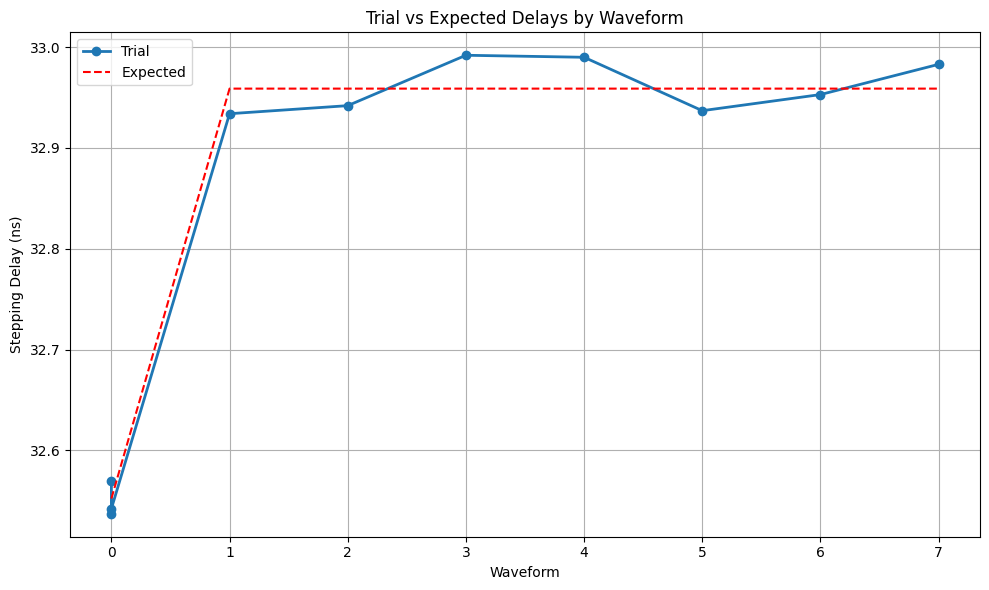

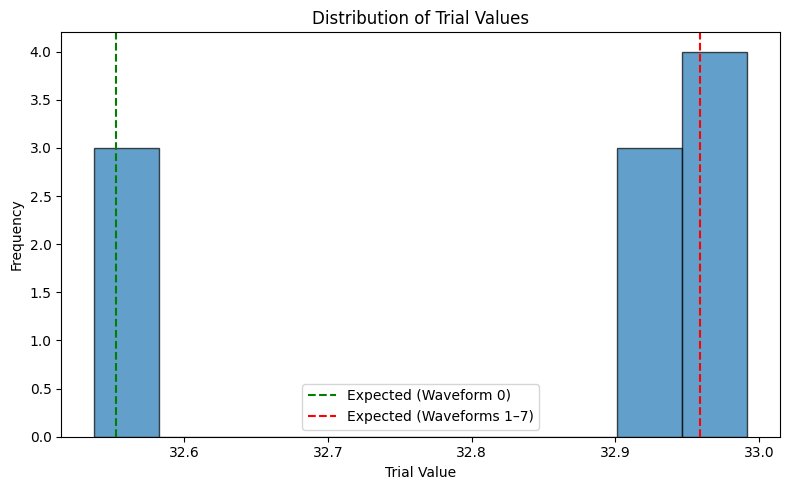

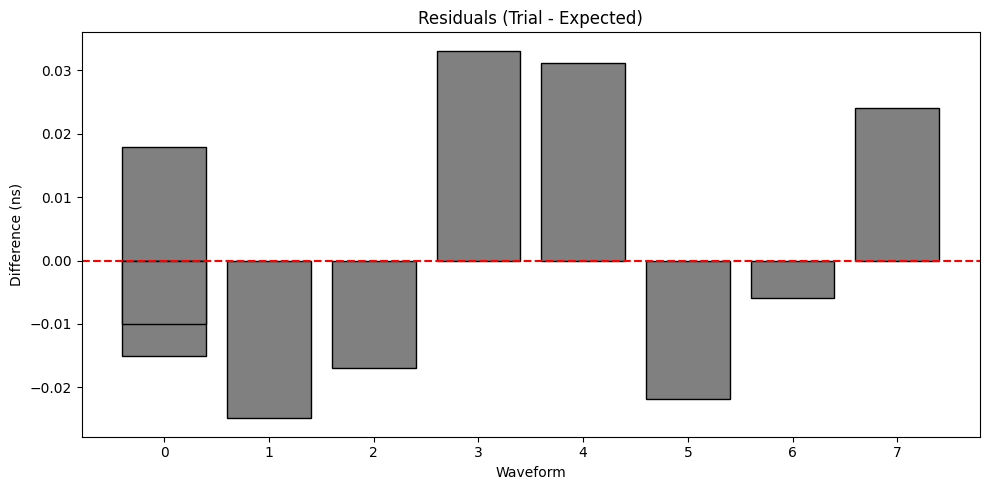

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Data setup ---
data = {
    "Waveform": [0, 0, 0, 1, 2, 3, 4, 5, 6, 7],
    "Expected": [32.55208]*3 + [32.9589]*7,
    "Trial": [
        32.570, 32.537, 32.542, 32.934, 32.942, 32.992, 32.990, 32.937, 32.953, 32.983
    ]
}

df = pd.DataFrame(data)

# --- Line plot: Trial vs Expected ---
plt.figure(figsize=(10, 6))
plt.plot(df["Waveform"], df["Trial"], marker='o', label="Trial", linewidth=2)
plt.plot(df["Waveform"], df["Expected"], linestyle='--', color='red', label="Expected")

plt.title("Trial vs Expected Delays by Waveform")
plt.xlabel("Waveform")
plt.ylabel("Stepping Delay (ns)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Distribution plot (Histogram) ---
plt.figure(figsize=(8, 5))
plt.hist(df["Trial"], bins=10, edgecolor='black', alpha=0.7)
plt.axvline(32.55208, color='green', linestyle='--', label="Expected (Waveform 0)")
plt.axvline(32.9589, color='red', linestyle='--', label="Expected (Waveforms 1–7)")

plt.title("Distribution of Trial Values")
plt.xlabel("Trial Value")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# --- Optional: Residuals plot (Trial - Expected) ---
df["Residual"] = df["Trial"] - df["Expected"]
plt.figure(figsize=(10, 5))
plt.bar(df["Waveform"], df["Residual"], color='gray', edgecolor='black')
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals (Trial - Expected)")
plt.xlabel("Waveform")
plt.ylabel("Difference (ns)")
plt.tight_layout()
plt.show()


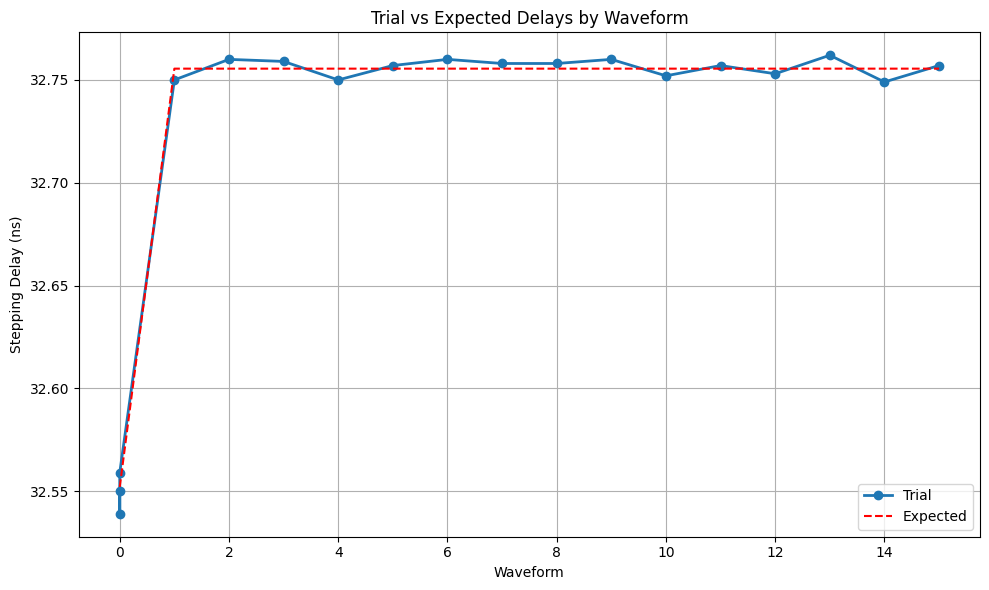

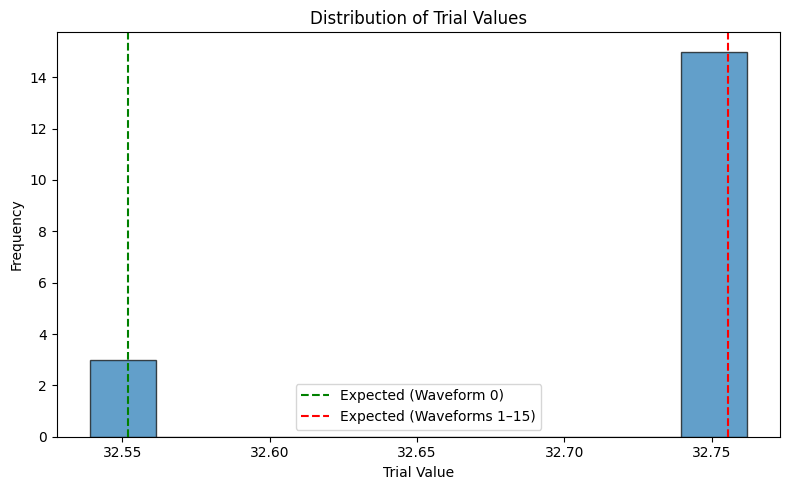

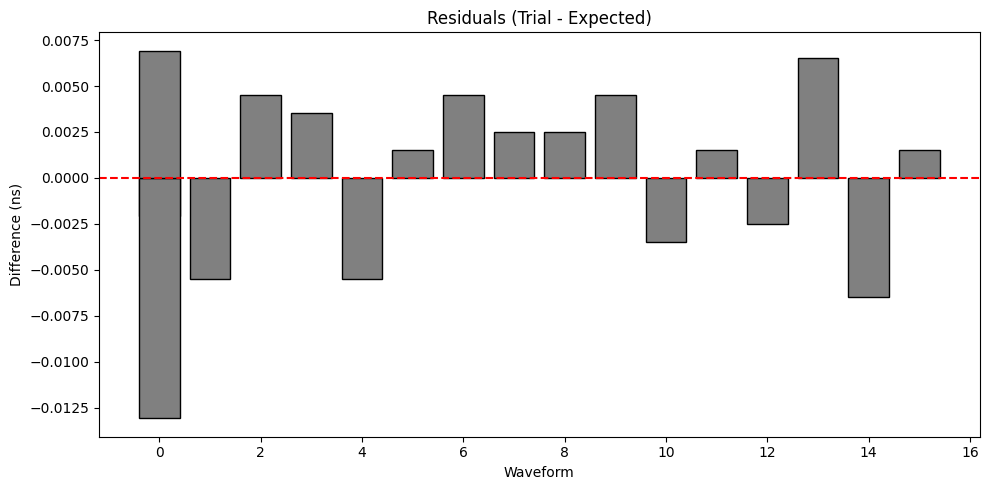

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Data setup ---
data = {
    "Waveform": [0, 0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    "Expected": [32.55208]*3 + [32.75549]*15,
    "Trial": [
        32.55, 32.539, 32.559, 32.75, 32.76, 32.759, 32.75, 32.757,
        32.76, 32.758, 32.758, 32.76, 32.752, 32.757, 32.753, 32.762,
        32.749, 32.757
    ]
}

df = pd.DataFrame(data)

# --- Line plot: Trial vs Expected ---
plt.figure(figsize=(10, 6))
plt.plot(df["Waveform"], df["Trial"], marker='o', label="Trial", linewidth=2)
plt.plot(df["Waveform"], df["Expected"], linestyle='--', color='red', label="Expected")

plt.title("Trial vs Expected Delays by Waveform")
plt.xlabel("Waveform")
plt.ylabel("Stepping Delay (ns)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Distribution plot (Histogram) ---
plt.figure(figsize=(8, 5))
plt.hist(df["Trial"], bins=10, edgecolor='black', alpha=0.7)
plt.axvline(32.55208, color='green', linestyle='--', label="Expected (Waveform 0)")
plt.axvline(32.75549, color='red', linestyle='--', label="Expected (Waveforms 1–15)")

plt.title("Distribution of Trial Values")
plt.xlabel("Trial Value")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# --- Optional: Residuals plot (Trial - Expected) ---
df["Residual"] = df["Trial"] - df["Expected"]
plt.figure(figsize=(10, 5))
plt.bar(df["Waveform"], df["Residual"], color='gray', edgecolor='black')
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals (Trial - Expected)")
plt.xlabel("Waveform")
plt.ylabel("Difference (ns)")
plt.tight_layout()
plt.show()


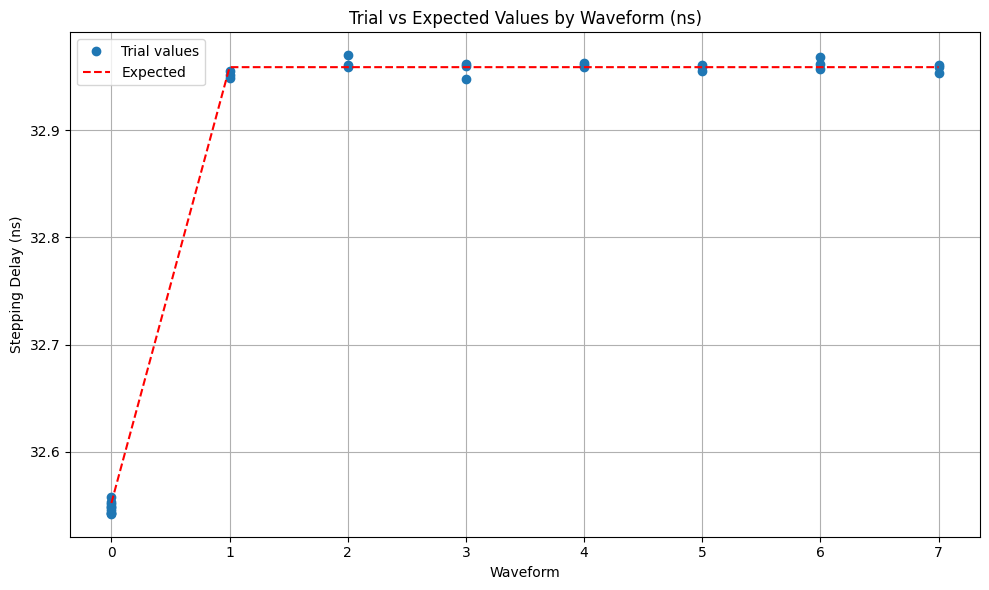

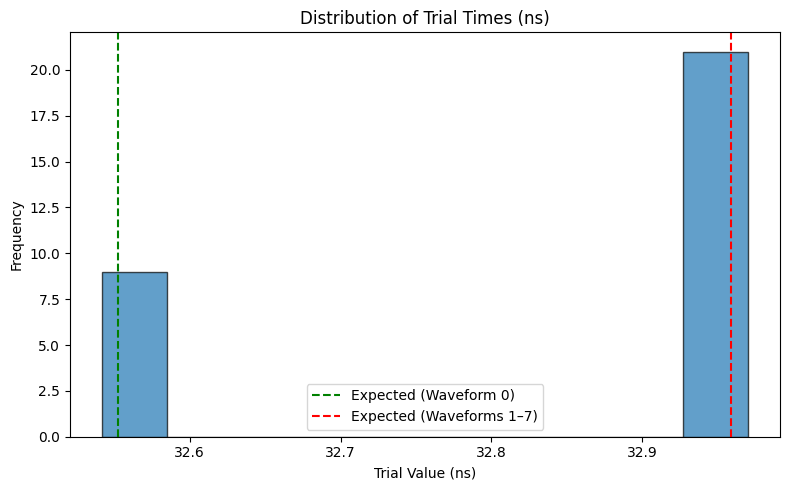

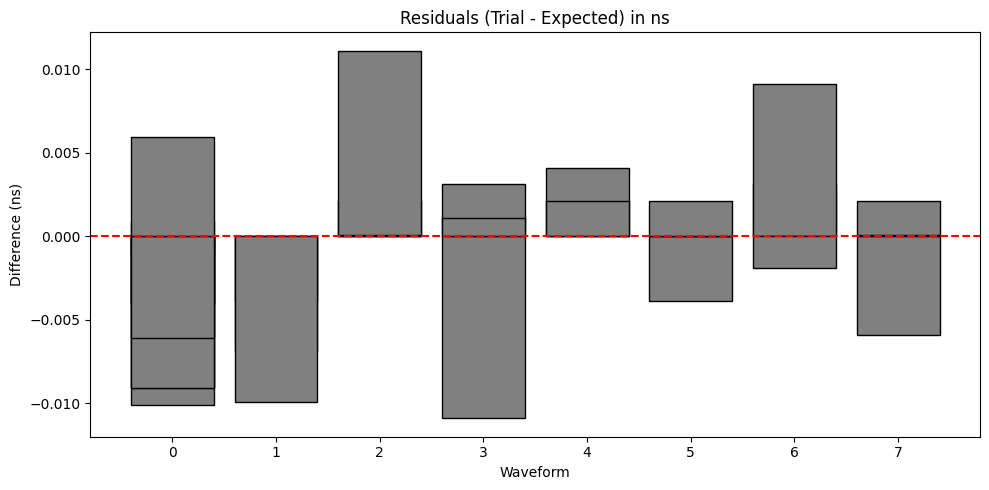

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Data setup ---
data = {
    "Waveform": [0,0,0,1,2,3,4,5,6,7],
    "Expected": [32.55208]*3 + [32.9589]*7,
    "Trial 1": [32.542, 32.543, 32.553, 32.955, 32.961, 32.962, 32.959, 32.955, 32.962, 32.961],
    "Trial 2": [32.543, 32.548, 32.551, 32.952, 32.97, 32.948, 32.963, 32.959, 32.968, 32.953],
    "Trial 3": [32.548, 32.546, 32.558, 32.949, 32.959, 32.96, 32.961, 32.961, 32.957, 32.959]
}

df = pd.DataFrame(data)

# --- Reshape the data: stack trials into a single column ---
df_melted = df.melt(
    id_vars=["Waveform", "Expected"],
    value_vars=["Trial 1", "Trial 2", "Trial 3"],
    var_name="Trial",
    value_name="Value (ns)"
)

# --- Line plot: Trial vs Expected ---
plt.figure(figsize=(10, 6))
plt.plot(df_melted["Waveform"], df_melted["Value (ns)"], 'o', label="Trial values")
plt.plot(df["Waveform"], df["Expected"], '--', color='red', label="Expected")

plt.title("Trial vs Expected Values by Waveform (ns)")
plt.xlabel("Waveform")
plt.ylabel("Stepping Delay (ns)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Distribution plot (Histogram) ---
plt.figure(figsize=(8, 5))
plt.hist(df_melted["Value (ns)"], bins=10, edgecolor='black', alpha=0.7)
plt.axvline(32.55208, color='green', linestyle='--', label="Expected (Waveform 0)")
plt.axvline(32.9589, color='red', linestyle='--', label="Expected (Waveforms 1–7)")

plt.title("Distribution of Trial Times (ns)")
plt.xlabel("Trial Value (ns)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# --- Optional: Residuals plot (Trial - Expected) ---
df_melted["Residual (ns)"] = df_melted["Value (ns)"] - df_melted["Expected"]
plt.figure(figsize=(10, 5))
plt.bar(df_melted["Waveform"], df_melted["Residual (ns)"], color='gray', edgecolor='black')
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals (Trial - Expected) in ns")
plt.xlabel("Waveform")
plt.ylabel("Difference (ns)")
plt.tight_layout()
plt.show()


C:\Users\vsmar\AppData\Local\Temp\ipykernel_40844\354119097.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


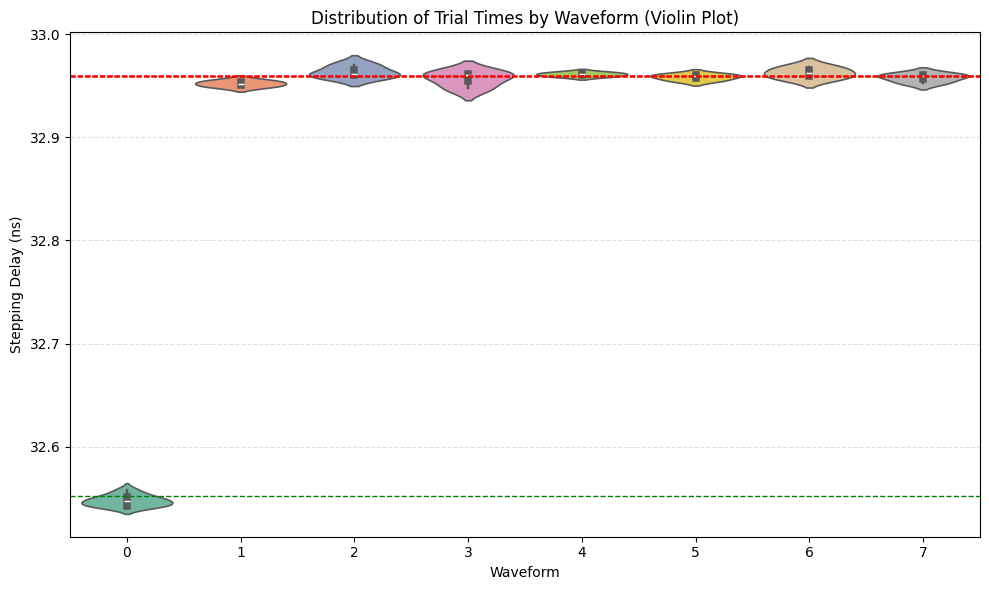

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # violin plots are easiest with seaborn

# --- Example DataFrame structure ---
# Replace this with your own data
data = {
    "Waveform": [0,0,0,1,2,3,4,5,6,7],
    "Expected": [32.55208]*3 + [32.9589]*7,
    "Trial 1": [32.542, 32.543, 32.553, 32.955, 32.961, 32.962, 32.959, 32.955, 32.962, 32.961],
    "Trial 2": [32.543, 32.548, 32.551, 32.952, 32.97, 32.948, 32.963, 32.959, 32.968, 32.953],
    "Trial 3": [32.548, 32.546, 32.558, 32.949, 32.959, 32.96, 32.961, 32.961, 32.957, 32.959]
}

df = pd.DataFrame(data)

# --- Melt to long form (required for violin plot) ---
df_melted = df.melt(
    id_vars=["Waveform", "Expected"],
    value_vars=["Trial 1", "Trial 2", "Trial 3"],
    var_name="Trial",
    value_name="Stepping Delay (ns)"
)

# --- Create Violin Plot ---
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_melted,
    x="Waveform",
    y="Stepping Delay (ns)",
    inner="box",     # show a mini boxplot inside each violin
    linewidth=1.2,
    palette="Set2"
)

# --- Add expected value lines for reference ---
for Waveform, exp_val in df.groupby("Waveform")["Expected"].first().items():
    plt.axhline(y=exp_val, color="red" if Waveform > 0 else "green", linestyle="--", linewidth=1)

plt.title("Distribution of Trial Times by Waveform (Violin Plot)")
plt.xlabel("Waveform")
plt.ylabel("Stepping Delay (ns)")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
